<a href="https://colab.research.google.com/github/IsuPaul/Indpendent-Research/blob/IR_Codes/IR_Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ENHANCED MACHINE LEARNING MODEL FOR 3D PRINTING CONCRETE COMPRESSIVE STRENGTH PREDICTION

## Imports

In [117]:
import pandas as pd
import numpy as np
import xgboost as xbt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import shap
import io
from sklearn.utils import resample
from sklearn.preprocessing import scale
from sklearn.tree import DecisionTreeRegressor
from sklearn import svm
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.inspection import PartialDependenceDisplay
from google.colab import files

## DATA MANAGEMENT AND CLEANING

### Visualization and Description of Uncleaned Data

#### Database Import

In [118]:
df = pd.read_csv('Datasets.csv', encoding='latin-1')

In [119]:
#df.head()

In [120]:
#df.describe()

### Determining the type of data in each column

In [121]:
#df.dtypes

### Converting all data to float

In [122]:
cols_to_convert = ['Carbonated RFA (Kg/m³)', 'PP (Kg/m³)', 'Silica Powder (Kg/m³)', 'AT (Kg/m³)']

for col in cols_to_convert:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)

# Displaying types to confirm
#print(df.dtypes)

### Checking for missing data

In [123]:
#df.isnull().sum()

### Fixing Missing Data

In [124]:
imputer_gbt = IterativeImputer(max_iter=10, random_state=42)
imputed_data=imputer_gbt.fit_transform(df)
imputed_data = np.maximum(imputed_data, 0)
imputed_df=pd.DataFrame(imputed_data,columns=df.columns)

### Reconfirm to check for missing data

In [125]:
#imputed_df.isnull().sum()

### Features Distributions

In [126]:
for i in imputed_df.columns:
    plt.figure(figsize=(2.5, 2.5))
    plt.hist(imputed_df[i])
    plt.xlabel(f"{i}",fontsize=7)
    plt.ylabel("Frequency",fontsize=7)
    plt.title(" ")
    plt.tight_layout()
    plt.savefig(f"{i.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.jpg")
    plt.close('all')

## MODEL DEVELOPEMENTS

#### Assigning Variables

In [127]:
X=imputed_df.drop('Compressive Strength (MPa)',axis=1).copy()
y=imputed_df['Compressive Strength (MPa)'].copy()

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

#### Scaling the dataframe and assigning variables for SVM and KNN

In [129]:
target_col = 'Compressive Strength (MPa)'
df_min = imputed_df.min()
df_max = imputed_df.max()
df_range = df_max - df_min
# Scale X_train and X_test using global stats
Xs_train = (X_train - df_min.drop(target_col)) / df_range.drop(target_col)
Xs_test = (X_test - df_min.drop(target_col)) / df_range.drop(target_col)
# Scale y_train and y_test using global stats
ys_train = (y_train - df_min[target_col]) / df_range[target_col]
ys_test = (y_test - df_min[target_col]) / df_range[target_col]

#### Hyperparameter Tunning of Models
Double-click the below cell, copy, and paste in a code field.

param_grids = {
    'XGBoost': {'learning_rate': [0.1, 0.2], 'max_depth': [1,3,4,], 'n_estimators': [500, 1000]},
    'SVM': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    'DecisionTree': {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    'KNN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
}

####### Models to optimize
models_to_tune = {
    'XGBoost': xbt.XGBRegressor(random_state=42),
    'SVM': svm.SVR(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor()
}

optimized_models = {}

####### Optimization and Evaluation Loop
for name, model in models_to_tune.items():
    print(f'Optimizing {name}...')
    is_scaled = name in ['SVM', 'KNN']
    cur_X_tr, cur_y_tr = (Xs_train, ys_train) if is_scaled else (X_train, y_train)
    cur_X_ts, cur_y_ts = (Xs_test, ys_test) if is_scaled else (X_test, y_test)

    grid = GridSearchCV(model, param_grids[name], cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(cur_X_tr, cur_y_tr)
    best_model_obj = grid.best_estimator_
    optimized_models[name] = best_model_obj

    print(f'Best Params for {name}: {grid.best_params_}')

    for d_name, x_set, y_set in [('Train', cur_X_tr, cur_y_tr), ('Test', cur_X_ts, cur_y_ts)]:
        preds = best_model_obj.predict(x_set)
        if is_scaled:
            y_actual = y_set * df_range[target_col] + df_min[target_col]
            p_actual = preds * df_range[target_col] + df_min[target_col]
        else:
            y_actual, p_actual = y_set, preds

        print(f'{name} {d_name} -> MAE: {mean_absolute_error(y_actual, p_actual):.4f}, RMSE: {np.sqrt(mean_squared_error(y_actual, p_actual)):.4f}, R2: {r2_score(y_actual, p_actual):.4f}')

In [130]:
param_grids = {
    'XGBoost': {'learning_rate': [0.1, 0.2], 'max_depth': [1,3,4,], 'n_estimators': [500, 1000]},
    'SVM': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
    'RandomForest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    'DecisionTree': {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    'KNN': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
}

####### Models to optimize
models_to_tune = {
    'XGBoost': xbt.XGBRegressor(random_state=42),
    'SVM': svm.SVR(),
    'RandomForest': RandomForestRegressor(random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor()
}

optimized_models = {}

####### Optimization and Evaluation Loop
for name, model in models_to_tune.items():
    print(f'Optimizing {name}...')
    is_scaled = name in ['SVM', 'KNN']
    cur_X_tr, cur_y_tr = (Xs_train, ys_train) if is_scaled else (X_train, y_train)
    cur_X_ts, cur_y_ts = (Xs_test, ys_test) if is_scaled else (X_test, y_test)

    grid = GridSearchCV(model, param_grids[name], cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(cur_X_tr, cur_y_tr)
    best_model_obj = grid.best_estimator_
    optimized_models[name] = best_model_obj

    print(f'Best Params for {name}: {grid.best_params_}')

    for d_name, x_set, y_set in [('Train', cur_X_tr, cur_y_tr), ('Test', cur_X_ts, cur_y_ts)]:
        preds = best_model_obj.predict(x_set)
        if is_scaled:
            y_actual = y_set * df_range[target_col] + df_min[target_col]
            p_actual = preds * df_range[target_col] + df_min[target_col]
        else:
            y_actual, p_actual = y_set, preds

        print(f'{name} {d_name} -> MAE: {mean_absolute_error(y_actual, p_actual):.4f}, RMSE: {np.sqrt(mean_squared_error(y_actual, p_actual)):.4f}, R2: {r2_score(y_actual, p_actual):.4f}')

Optimizing XGBoost...
Best Params for XGBoost: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 1000}
XGBoost Train -> MAE: 0.4829, RMSE: 1.5770, R2: 0.9968
XGBoost Test -> MAE: 3.3601, RMSE: 4.7837, R2: 0.9724
Optimizing SVM...
Best Params for SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
SVM Train -> MAE: 8.6497, RMSE: 10.4096, R2: 0.8604
SVM Test -> MAE: 9.0763, RMSE: 11.2146, R2: 0.8484
Optimizing RandomForest...
Best Params for RandomForest: {'max_depth': None, 'n_estimators': 200}
RandomForest Train -> MAE: 2.0812, RMSE: 3.2943, R2: 0.9860
RandomForest Test -> MAE: 3.8848, RMSE: 5.7332, R2: 0.9604
Optimizing DecisionTree...
Best Params for DecisionTree: {'max_depth': 10, 'min_samples_split': 2}
DecisionTree Train -> MAE: 2.4968, RMSE: 4.5033, R2: 0.9739
DecisionTree Test -> MAE: 5.2753, RMSE: 8.0143, R2: 0.9226
Optimizing KNN...
Best Params for KNN: {'n_neighbors': 5, 'weights': 'distance'}
KNN Train -> MAE: 0.4762, RMSE: 1.5769, R2: 0.9968
KNN Test -> MAE: 5.7135, RMSE:

### EXTREME GRADIENT BOOSTING

#### Training the model

In [131]:
clf=xbt.XGBRegressor()
clf.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

#### Model Validation

##### Evaluation of Training Data

In [132]:
y_pred = clf.predict(X_train)
mse=mean_squared_error(y_train, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_train, y_pred)
maer_xA=mean_absolute_error(y_train, y_pred)
print("Mean Absolute Error:", maer_xA)
print("Root Mean Squared Error:", rmse)
print("R-Squared Score:", r2)

Mean Absolute Error: 0.6202199883866816
Root Mean Squared Error: 1.5965955626174413
R-Squared Score: 0.9967168480685068


##### Evaluation of Testing Data

In [133]:
y_pred = clf.predict(X_test)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)
maer_xA=mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", maer_xA)
print("Root Mean Squared Error:", rmse)
print("R-Squared Score:", r2)

Mean Absolute Error: 3.4798958325090488
Root Mean Squared Error: 4.880272101388487
R-Squared Score: 0.9712921297809599


#### Optimize Model to XGBOOST+

##### Trained Model

In [134]:
parameters={ 'learning_rate': [0.2] , 'max_depth':  [4] , 'n_estimators': [1000] }
model= xbt.XGBRegressor()
best_model=GridSearchCV(model, parameters, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
best_model.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=Non...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.2], 'max_depth': [4],
                         'n_estimators': [1000]},
             scoring='neg_mean_squared_error')

##### Evaluation of Training Data

In [135]:
y_predict=best_model.predict(X_train)
mse1=mean_squared_error(y_train, y_predict)
rmse1=np.sqrt(mse1)
r21=r2_score(y_train, y_predict)
maer_x=mean_absolute_error(y_train, y_predict)
print("Mean Absolute Error:", maer_x)
print("Root Mean Squared Error:", rmse1)
print("R-Squared Score:", r21)

Mean Absolute Error: 0.48285498715038844
Root Mean Squared Error: 1.5769628829451252
R-Squared Score: 0.9967970947767296


##### Evaluation of Testing Data

In [136]:
y_predict=best_model.predict(X_test)
mse1=mean_squared_error(y_test, y_predict)
rmse1=np.sqrt(mse1)
r21=r2_score(y_test, y_predict)
maer_x=mean_absolute_error(y_test, y_predict)
print("Mean Absolute Error:", maer_x)
print("Root Mean Squared Error:", rmse1)
print("R-Squared Score:", r21)

Mean Absolute Error: 3.3600906478373473
Root Mean Squared Error: 4.7837082709127525
R-Squared Score: 0.9724169508033963


### SUPPORT VECTOR MACHINE MODEL

#### Training the model

In [137]:
SVM_Params = {'C': [10], 'gamma': ['auto'], 'kernel': ['rbf']}
model_svm_best = svm.SVR()
model_svm=GridSearchCV(model_svm_best, SVM_Params, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
model_svm.fit(Xs_train, ys_train)

GridSearchCV(cv=10, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [10], 'gamma': ['auto'], 'kernel': ['rbf']},
             scoring='neg_mean_squared_error')

#### Model Validation

##### Evaluation of Training Data

In [138]:
ys_pred_scaled = model_svm.predict(Xs_train)
# Inverse scaling
ys_pred = ys_pred_scaled * df_range[target_col] + df_min[target_col]

mses=mean_squared_error(y_train, ys_pred)
rmses=np.sqrt(mses)
r2s=r2_score(y_train, ys_pred)
maer_xs=mean_absolute_error(y_train, ys_pred)
print("Mean Absolute Error:", maer_xs)
print("Root Mean Squared Error:", rmses)
print("R-Squared Score:", r2s)

Mean Absolute Error: 8.649720374144371
Root Mean Squared Error: 10.409610027893104
R-Squared Score: 0.8604370744116203


##### Evaluation of Testing Data

In [139]:
ys_pred_scaled = model_svm.predict(Xs_test)
# Inverse scaling
ys_pred = ys_pred_scaled * df_range[target_col] + df_min[target_col]

mses=mean_squared_error(y_test, ys_pred)
rmses=np.sqrt(mses)
r2s=r2_score(y_test, ys_pred)
maer_xs=mean_absolute_error(y_test, ys_pred)
print("Mean Absolute Error:", maer_xs)
print("Root Mean Squared Error:", rmses)
print("R-Squared Score:", r2s)

Mean Absolute Error: 9.07634391404322
Root Mean Squared Error: 11.214639117466113
R-Squared Score: 0.848405478750331


### RANDOM FOREST

#### Training the model

In [140]:
RF_Params = {'n_estimators': [200], 'max_depth': [None]}
model_rf_best=RandomForestRegressor(random_state=42)
model_rf=GridSearchCV(model_rf_best, RF_Params, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
model_rf.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None], 'n_estimators': [200]},
             scoring='neg_mean_squared_error')

#### Model Validation

##### Evaluation of Training Data

In [141]:
yr_pred = model_rf.predict(X_train)
mser=mean_squared_error(y_train, yr_pred)
rmser=np.sqrt(mser)
maer=mean_absolute_error(y_train, yr_pred)
r2r=r2_score(y_train, yr_pred)
print("Mean Absolute Error:", maer)
print("Root Mean Squared Error:", rmser)
print("R-Squared Score:", r2r)

Mean Absolute Error: 2.0812405858611442
Root Mean Squared Error: 3.2943017403566768
R-Squared Score: 0.9860225516462942


##### Evaluation of Testing Data

In [142]:
yr_pred = model_rf.predict(X_test)
mser=mean_squared_error(y_test, yr_pred)
rmser=np.sqrt(mser)
maer=mean_absolute_error(y_test, yr_pred)
r2r=r2_score(y_test, yr_pred)
print("Mean Absolute Error:", maer)
print("Root Mean Squared Error:", rmser)
print("R-Squared Score:", r2r)

Mean Absolute Error: 3.88478837875508
Root Mean Squared Error: 5.733241894007368
R-Squared Score: 0.960380094826874


### DECISION TREE

#### Training the model

In [143]:
DT_Params = {'max_depth': [10], 'min_samples_split': [2]}
model_dt_best=DecisionTreeRegressor(random_state=42)
model_dt=GridSearchCV(model_dt_best, DT_Params, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
model_dt.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10], 'min_samples_split': [2]},
             scoring='neg_mean_squared_error')

#### Model Validation

##### Evaluation of Training Data

In [144]:
yd_pred = model_dt.predict(X_train)
msed=mean_squared_error(y_train, yd_pred)
rmsed=np.sqrt(msed)
maed=mean_absolute_error(y_train, yd_pred)
r2d=r2_score(y_train, yd_pred)
print("Mean Absolute Error:", maed)
print("Root Mean Squared Error:", rmsed)
print("R-Squared Score:", r2d)

Mean Absolute Error: 2.496758631821523
Root Mean Squared Error: 4.503325203183572
R-Squared Score: 0.9738803252113543


##### Evaluation of Testing Data

In [145]:
yd_pred = model_dt.predict(X_test)
msed=mean_squared_error(y_test, yd_pred)
rmsed=np.sqrt(msed)
maed=mean_absolute_error(y_test, yd_pred)
r2d=r2_score(y_test, yd_pred)
print("Mean Absolute Error:", maed)
print("Root Mean Squared Error:", rmsed)
print("R-Squared Score:", r2d)

Mean Absolute Error: 5.275336643748408
Root Mean Squared Error: 8.014345454829195
R-Squared Score: 0.9225807397055085


### MULTILINEAR REGRESSION

#### Training the model

In [146]:
model_ml=LinearRegression()
model_ml.fit(X_train, y_train)

LinearRegression()

#### Model Validation

##### Evaluation of Training Data

In [147]:
ym_pred = model_ml.predict(X_train)
msem=mean_squared_error(y_train, ym_pred)
rmsem=np.sqrt(msem)
maem=mean_absolute_error(y_train, ym_pred)
r2m=r2_score(y_train, ym_pred)
print("Mean Absolute Error:", maem)
print("Root Mean Squared Error:", rmsem)
print("R-Squared Score:", r2m)

Mean Absolute Error: 5.755305081158454
Root Mean Squared Error: 8.026372411859414
R-Squared Score: 0.9170264335402404


##### Evaluation of Testing Data

In [148]:
ym_pred = model_ml.predict(X_test)
msem=mean_squared_error(y_test, ym_pred)
rmsem=np.sqrt(msem)
maem=mean_absolute_error(y_test, yd_pred)
r2m=r2_score(y_test, ym_pred)
print("Mean Absolute Error:", maem)
print("Root Mean Squared Error:", rmsem)
print("R-Squared Score:", r2m)

Mean Absolute Error: 5.275336643748408
Root Mean Squared Error: 9.324827820736402
R-Squared Score: 0.8951919735267084


### KNN NEIGHBORS

#### Training the model

In [149]:
KN_Params = {'n_neighbors': [5], 'weights': ['distance']}
model_kn_best=KNeighborsRegressor(2)
model_kn=GridSearchCV(model_kn_best, KN_Params, cv=10, scoring="neg_mean_squared_error", n_jobs=-1)
# Using scaled data for KNN
model_kn.fit(Xs_train, ys_train)

GridSearchCV(cv=10, estimator=KNeighborsRegressor(n_neighbors=2), n_jobs=-1,
             param_grid={'n_neighbors': [5], 'weights': ['distance']},
             scoring='neg_mean_squared_error')

#### Model Validation

##### Evaluation of Training Data

In [150]:
yk_pred_scaled = model_kn.predict(Xs_train)
# Inverse scaling
yk_pred = yk_pred_scaled * df_range[target_col] + df_min[target_col]

msek=mean_squared_error(y_train, yk_pred)
rmsek=np.sqrt(msek)
maek=mean_absolute_error(y_train, yk_pred)
r2k=r2_score(y_train, yk_pred)
print("Mean Absolute Error:", maek)
print("Root Mean Squared Error:", rmsek)
print("R-Squared Score:", r2k)

Mean Absolute Error: 0.4762100090848138
Root Mean Squared Error: 1.5769048978587739
R-Squared Score: 0.996797330314704


##### Evaluating Testing Data

In [151]:
yk_pred_scaled = model_kn.predict(Xs_test)
# Inverse scaling
yk_pred = yk_pred_scaled * df_range[target_col] + df_min[target_col]

msek=mean_squared_error(y_test, yk_pred)
rmsek=np.sqrt(msek)
maek=mean_absolute_error(y_test, yk_pred)
r2k=r2_score(y_test, yk_pred)
print("Mean Absolute Error:", maek)
print("Root Mean Squared Error:", rmsek)
print("R-Squared Score:", r2k)

Mean Absolute Error: 5.713507934309565
Root Mean Squared Error: 8.523788251873123
R-Squared Score: 0.9124253913530912


### XGBOOST - Material and Printing Parameter Models

### Material Model

In [152]:
columns_to_remove = ['Nozzle Speed (mm/s)', 'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']
X_material = imputed_df.drop(columns_to_remove, axis=1).drop('Compressive Strength (MPa)', axis=1).copy()
y_material = imputed_df['Compressive Strength (MPa)'].copy()

X_train_mat, X_test_mat, y_train_mat, y_test_mat = train_test_split(X_material, y_material, test_size=0.3, random_state=42)

model_material = xbt.XGBRegressor()
model_material.fit(X_train_mat, y_train_mat)

y_predict_mat = model_material.predict(X_test_mat)

mse_mat = mean_squared_error(y_test_mat, y_predict_mat)
rmse_mat = np.sqrt(mse_mat)
r2_mat = r2_score(y_test_mat, y_predict_mat)
mae_mat = mean_absolute_error(y_test_mat, y_predict_mat)

print("--- Material Model Results ---")
print("Mean Absolute Error:", mae_mat)
print("Root Mean Squared Error:", rmse_mat)
print("R-Squared Score:", r2_mat)

--- Material Model Results ---
Mean Absolute Error: 4.610374470486129
Root Mean Squared Error: 6.578165333116978
R-Squared Score: 0.9478418150822137


### Printing Model

In [153]:
X_printing = imputed_df[['Nozzle Speed (mm/s)', 'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']].copy()
y_printing = imputed_df['Compressive Strength (MPa)'].copy()

X_train_print, X_test_print, y_train_print, y_test_print = train_test_split(X_printing, y_printing, test_size=0.3, random_state=42)

model_printing = xbt.XGBRegressor()
model_printing.fit(X_train_print, y_train_print)

y_predict_print = model_printing.predict(X_test_print)

mse_print = mean_squared_error(y_test_print, y_predict_print)
rmse_print = np.sqrt(mse_print)
r2_print = r2_score(y_test_print, y_predict_print)
mae_print = mean_absolute_error(y_test_print, y_predict_print)

print("--- Printing Model Results ---")
print("Mean Absolute Error:", mae_print)
print("Root Mean Squared Error:", rmse_print)
print("R-Squared Score:", r2_print)

--- Printing Model Results ---
Mean Absolute Error: 7.080698582121163
Root Mean Squared Error: 11.982427295053917
R-Squared Score: 0.8269376863542055


## VISUALIZATION OF MODEL PERFORMANCE

### Learning Curves

Saved: LC_MSE_XGBOOST+.jpg


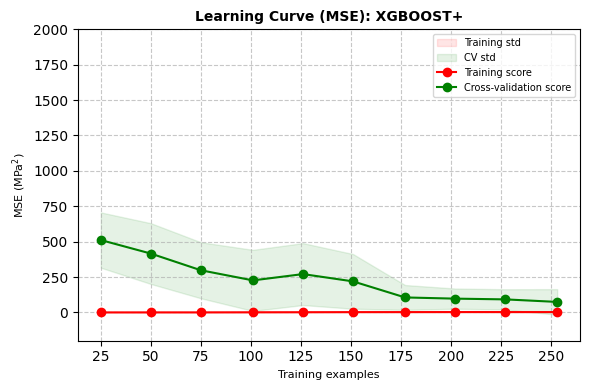

Saved: LC_MSE_SVM.jpg


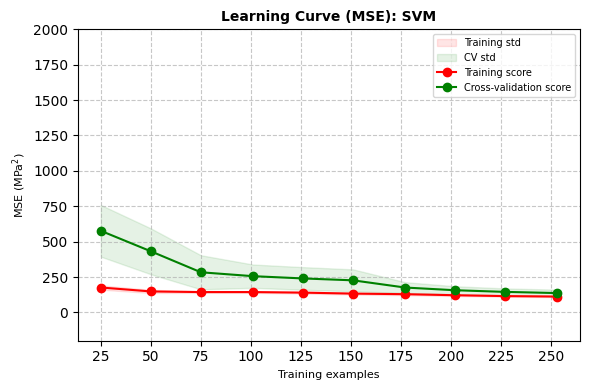

Saved: LC_MSE_RF.jpg


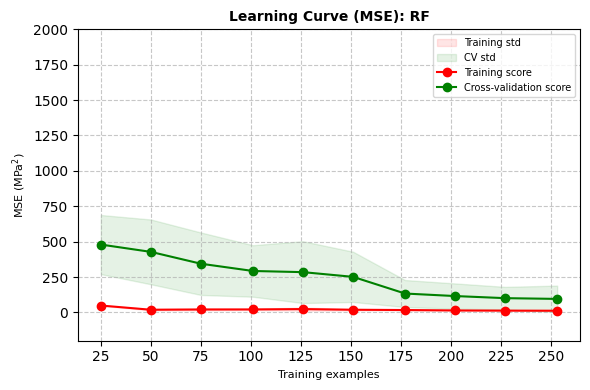

Saved: LC_MSE_DT.jpg


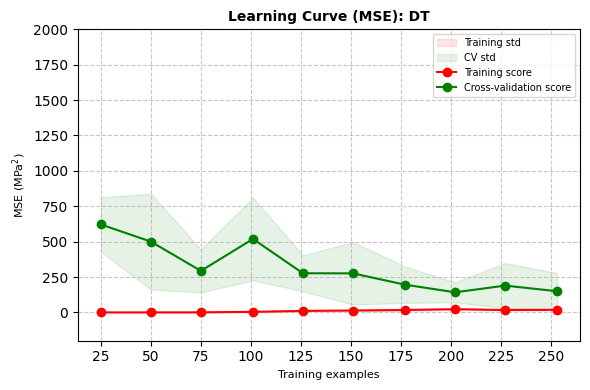

Saved: LC_MSE_MLR.jpg


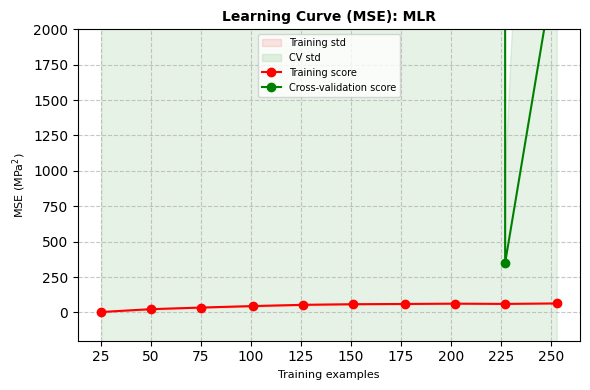

Saved: LC_MSE_KNN.jpg


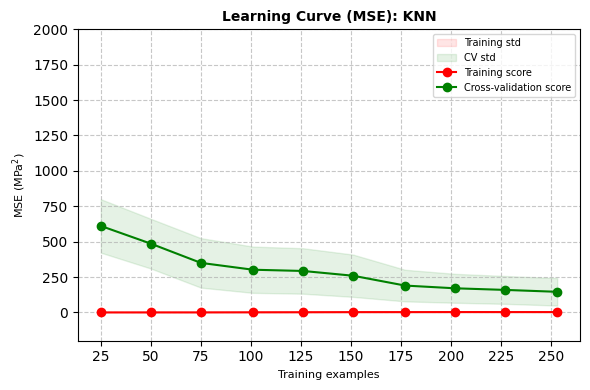

In [154]:
def plot_learning_curve_mse(estimator, title, X_data, y_data, axes, ylim=None, cv=10, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10), is_scaled=False):
    # Using neg_mean_squared_error for MSE
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_data, y_data, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='neg_mean_squared_error')

    # Convert negative MSE to positive
    train_scores_mean = (-train_scores).mean(axis=1)
    train_scores_std = (-train_scores).std(axis=1)
    test_scores_mean = (-test_scores).mean(axis=1)
    test_scores_std = (-test_scores).std(axis=1)

    # Inverse scale the MSE if the model was trained on scaled data
    if is_scaled:
        # Since MSE is in units^2, we multiply by the square of the range
        scale_factor = (df_range[target_col]) ** 2
        train_scores_mean *= scale_factor
        train_scores_std *= scale_factor
        test_scores_mean *= scale_factor
        test_scores_std *= scale_factor

    axes.grid(True, linestyle='--', alpha=0.7)
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r", label="Training std")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g", label="CV std")

    axes.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    axes.xaxis.set_major_locator(ticker.MultipleLocator(25))
    axes.set_title(title, fontsize=10, fontweight='bold')
    axes.set_xlabel("Training examples", fontsize=8)
    axes.set_ylabel("MSE (MPa$^2$)", fontsize=8)
    if ylim:
        axes.set_ylim(*ylim)
    axes.legend(loc="best", fontsize=7)

# Define models to plot with their specific data sets
models_mse = [
    (best_model.best_estimator_, "XGBOOST+", X_train, y_train, False),
    (model_svm.best_estimator_, "SVM", Xs_train, ys_train, True),
    (model_rf.best_estimator_, "RF", X_train, y_train, False),
    (model_dt.best_estimator_, "DT", X_train, y_train, False),
    (model_ml, "MLR", X_train, y_train, False),
    (model_kn.best_estimator_, "KNN", Xs_train, ys_train, True)
]

# Set a common Y-limit for all MSE plots for easier comparison
common_ylim_mse = (-200, 2000)

for name, model_tuple in zip([m[1] for m in models_mse], models_mse):
    est, model_name, x_curr, y_curr, is_scaled = model_tuple

    fig, ax = plt.subplots(figsize=(6, 4))
    plot_learning_curve_mse(est, f"Learning Curve (MSE): {model_name}", x_curr, y_curr, ax, ylim=common_ylim_mse, is_scaled=is_scaled)

    filename = f"LC_MSE_{model_name.replace(' ', '_')}.jpg"
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")
    plt.show()
    plt.close(fig)

### XGBOOST Error Loss Curves

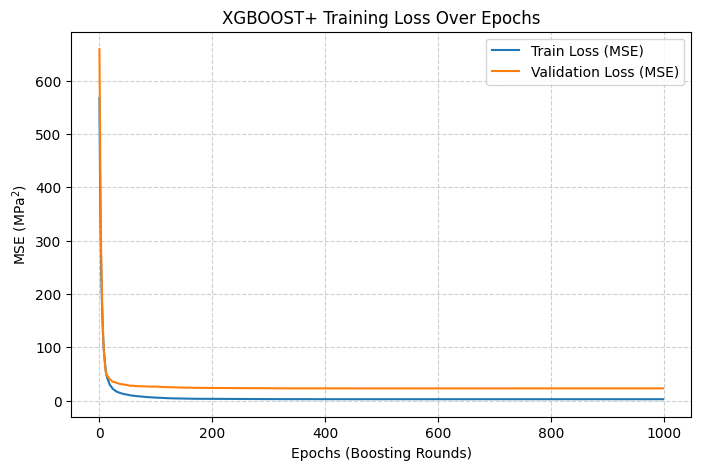

In [155]:


# To get loss over epochs, we must re-fit the best XGBoost model with an eval_set
xgb_best = best_model.best_estimator_

xgb_best.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

results = xgb_best.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

# Plotting MSE (Internal XGBoost RMSE squared)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_axis, np.square(results['validation_0']['rmse']), label='Train Loss (MSE)')
ax.plot(x_axis, np.square(results['validation_1']['rmse']), label='Validation Loss (MSE)')
ax.legend()
plt.ylabel('MSE (MPa$^2$)')
plt.xlabel('Epochs (Boosting Rounds)')
plt.title('XGBOOST+ Training Loss Over Epochs')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('XGBoost_Loss_Epochs.jpg', dpi=300)
plt.show()

### Scatter Plot of all Models

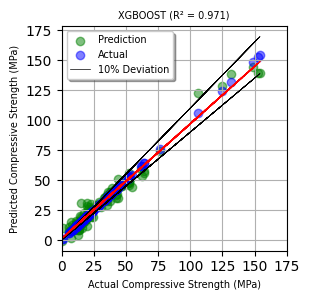

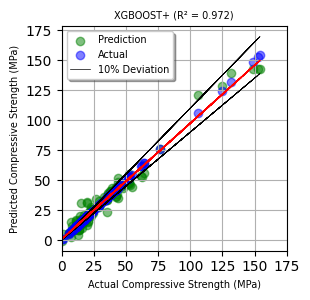

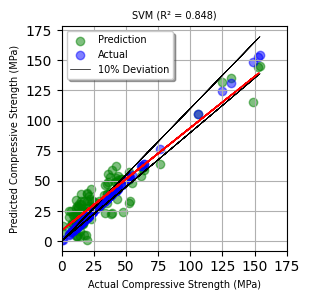

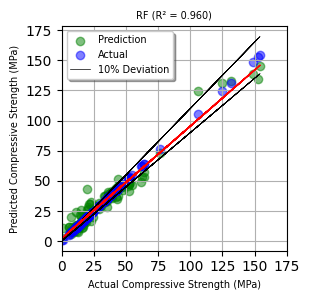

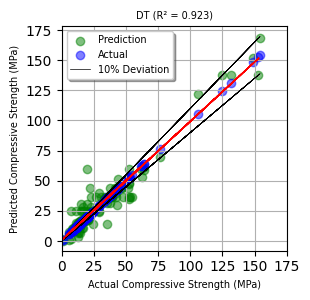

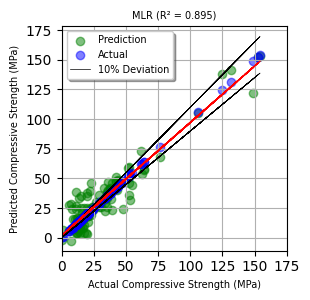

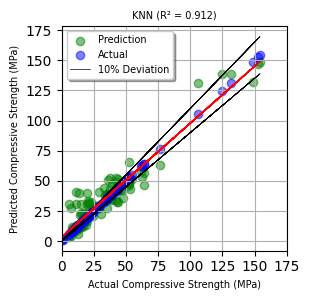

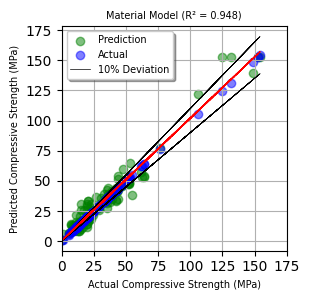

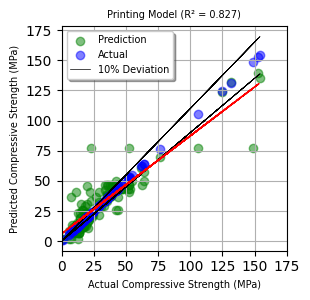

In [156]:
def plot_model_scatter(name, y_true, y_pred, r2_val, filename):
    deviation = 0.10 * y_true
    lower_bound = y_true - deviation
    upper_bound = y_true + deviation

    plt.figure(figsize=(3.2, 3.1))
    plt.scatter(y_true, y_pred, color='green', alpha=0.5, label='Prediction')
    plt.scatter(y_true, y_true, color='blue', alpha=0.5, label='Actual')
    plt.plot(y_true, lower_bound, color='black', linewidth=0.5, label='10% Deviation')
    plt.plot(y_true, upper_bound, color='black', linewidth=0.5)

    m, b = np.polyfit(y_true, y_pred, 1)
    plt.plot(y_true, m * y_true + b, 'r--', lw=1)

    plt.xlabel('Actual Compressive Strength (MPa)', fontsize=7)
    plt.ylabel('Predicted Compressive Strength (MPa)', fontsize=7)
    plt.title(f'{name} (R² = {r2_val:.3f})', fontsize=7)
    plt.xlim(0, 175)
    plt.xticks(np.arange(0, 200, 25))
    plt.grid(True)
    plt.legend(fontsize=7, shadow=True, facecolor='white')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plots_config = [
    ('XGBOOST', y_test, y_pred, r2, 'R2_XGBOOST.jpg'),
    ('XGBOOST+', y_test, y_predict, r21, 'R2_XGBOOST+.jpg'),
    ('SVM', y_test, ys_pred, r2s, 'R2_SVM.jpg'),
    ('RF', y_test, yr_pred, r2r, 'R2_RF.jpg'),
    ('DT', y_test, yd_pred, r2d, 'R2_DT.jpg'),
    ('MLR', y_test, ym_pred, r2m, 'R2_MLR.jpg'),
    ('KNN', y_test, yk_pred, r2k, 'R2_KNN.jpg'),
    ('Material Model', y_test_mat, y_predict_mat, r2_mat, 'R2_Material.jpg'),
    ('Printing Model', y_test_print, y_predict_print, r2_print, 'R2_Printing.jpg')
]

for name, y_t, y_p, r2_v, fname in plots_config:
    plot_model_scatter(name, y_t, y_p, r2_v, fname)

### Residual Plots

Saved: Residuals_XGBOOSTplus.jpg


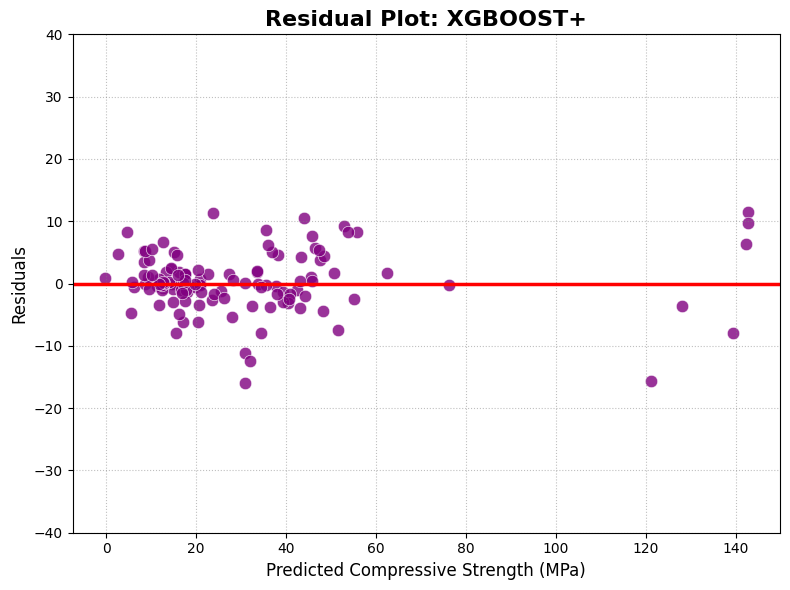

Saved: Residuals_SVM.jpg


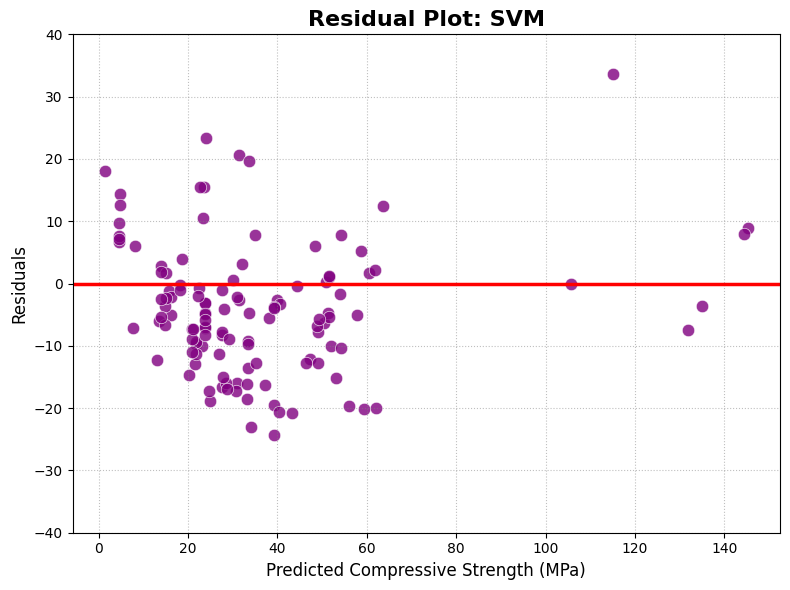

Saved: Residuals_RF.jpg


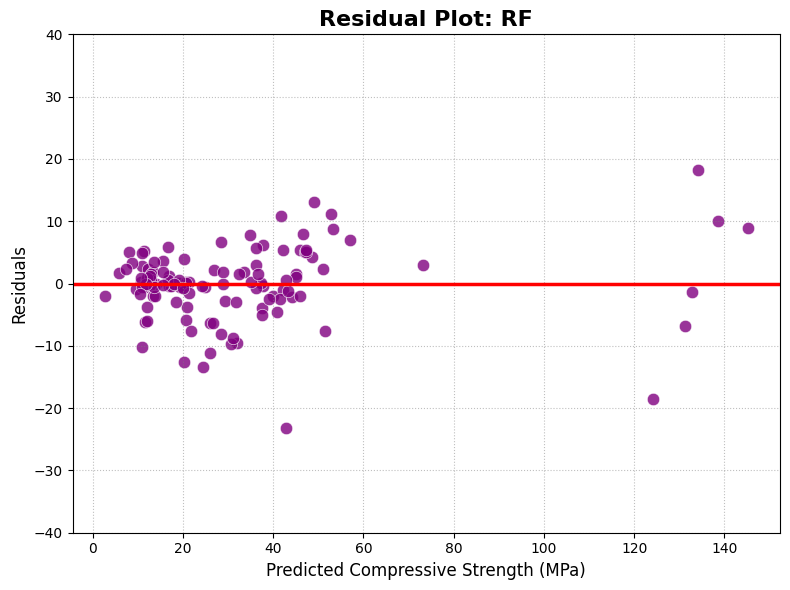

Saved: Residuals_DT.jpg


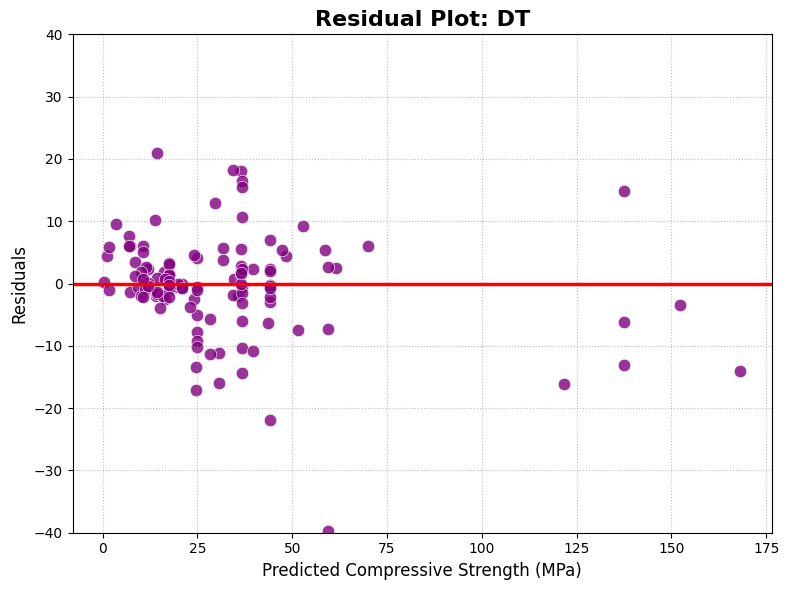

Saved: Residuals_MLR.jpg


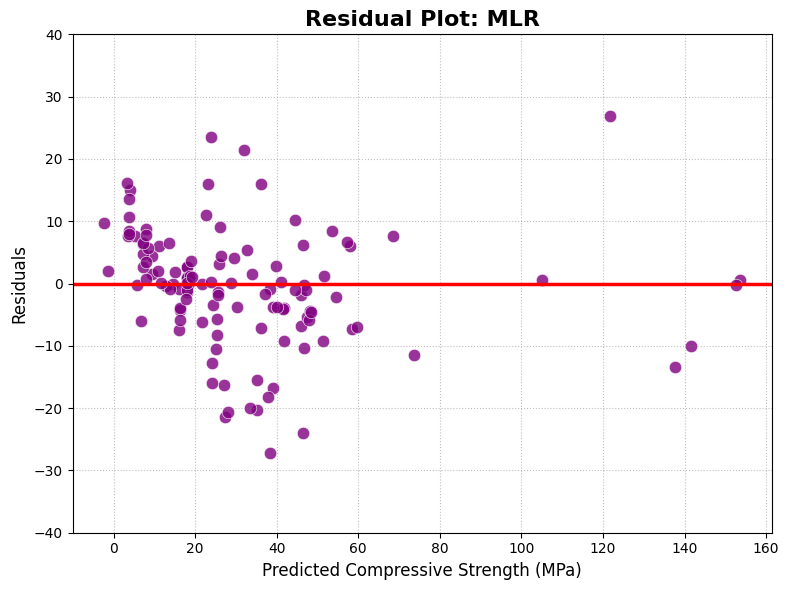

Saved: Residuals_KNN.jpg


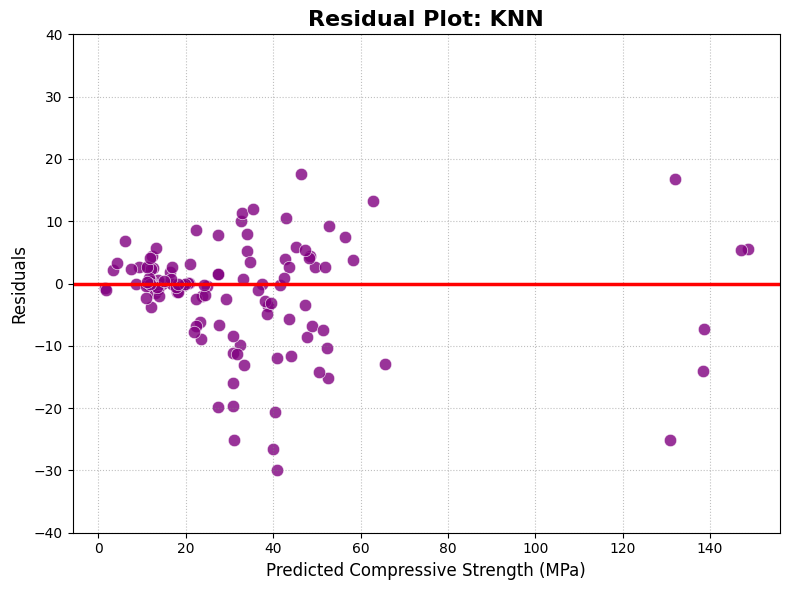

In [157]:
def plot_residuals_individual(name, y_true, y_pred, ylim=None):
    plt.figure(figsize=(8, 6), facecolor='white')
    residuals = y_true - y_pred
    plt.scatter(y_pred, residuals, alpha=0.8, color='purple', edgecolors='white', s=80, linewidth=0.5)
    plt.axhline(0, color='red', linestyle='-', lw=2.5, alpha=1.0)
    plt.title(f'Residual Plot: {name}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Compressive Strength (MPa)', fontsize=12)
    plt.ylabel('Residuals', fontsize=12)
    if ylim:
        plt.ylim(ylim)
    plt.grid(True, linestyle=':', alpha=0.5, color='gray')
    filename = f"Residuals_{name.replace('+', 'plus').replace(' ', '_')}.jpg"
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")
    plt.show()
    plt.close()

# Note: model_results expects unscaled predictions for the plot comparison
model_results = [
    ('XGBOOST+', best_model.predict(X_test)),
    ('SVM', ys_pred), # ys_pred is now unscaled
    ('RF', model_rf.predict(X_test)),
    ('DT', model_dt.predict(X_test)),
    ('MLR', model_ml.predict(X_test)),
    ('KNN', yk_pred)  # yk_pred is now unscaled
]

common_resid_ylim = (-40, 40)

for name, y_p in model_results:
    plot_residuals_individual(name, y_test, y_p, ylim=common_resid_ylim)

### SHAP ANALYSIS

In [158]:
# SHAP values
explainer = shap.TreeExplainer(best_model.best_estimator_)
shap_values = explainer.shap_values(X_test)

In [159]:
# Plot SHAP summary with minimized height
plt.figure(figsize=(4, 4))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, show=False)
plt.gca().set_title(" ")
plt.savefig("SHAP1.jpg")
plt.close()

In [160]:
#Waterfall Plot
exp=shap.Explainer(best_model.best_estimator_)
shap_values = exp(X_test)
plt.figure(figsize=(3.2, 3.4))
shap.plots.waterfall(shap_values[104], show=False)
plt.tight_layout()
plt.savefig("WATERFALL.jpg")
plt.close()

In [161]:
#Feature Importance
plt.figure(figsize=(4, 2))
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("BAR_IMPORTANCE.jpg")
plt.close()

In [162]:
#Partial Dependence Plot (PDP)
for i in X_test.columns:
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    PartialDependenceDisplay.from_estimator(best_model, X_test, [i], ax=ax)
    ax.set_xlabel(f"{i}", fontsize=8)
    ax.set_ylabel("Partial Dependence", fontsize=8)
    ax.set_title(f" ")
    plt.tight_layout()
    plt.savefig(f" PDP of {i.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}.jpg")
    plt.close()

/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
/usr/local/lib/python3.12/dist-p

# UPLOAD EXCEL OR CSV FILE TO PREDICT COMPRESSIVE STRENGTH USING THE XGBOOST+ MODEL

In [163]:
print("Please upload your file (.xlsx or .csv) containing the feature columns:")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    file_content = io.BytesIO(uploaded[file_name])

    if file_name.endswith('.csv'):
        user_df = pd.read_csv(file_content, encoding='latin-1')
    else:
        user_df = pd.read_excel(file_content)

    required_features = X.columns.tolist()

    priority_features = ['Cement (Kg/m³)', 'Water (Kg/m³)', 'Age (Days)', 'Nozzle Speed (mm/s)',
                         'Fine Aggregate (Kg/m³)', 'Silica Fume (Kg/m³)', 'Fly ash (Kg/m³)',
                         'DIA (mm)', 'Layer Depth (mm)', 'Layer Width (mm)']

    other_features = [f for f in required_features if f not in priority_features]
    mapping_order = sorted(priority_features, key=len, reverse=True) + sorted(other_features, key=len, reverse=True)

    model_input = pd.DataFrame(index=user_df.index)
    user_cols = [str(c).strip() for c in user_df.columns]
    user_cols_lower = [c.lower() for c in user_cols]
    used_indices = set()

    for feature in mapping_order:
        found = False
        feature_keyword = feature.lower().split('(')[0].strip()

        # Step A: Exact Match
        for i, u_col in enumerate(user_cols_lower):
            if i not in used_indices and (feature_keyword == u_col or feature.lower() == u_col):
                model_input[feature] = user_df.iloc[:, i]
                used_indices.add(i)
                found = True
                break

        # Step B: Keyword Match
        if not found:
            for i, u_col in enumerate(user_cols_lower):
                if i not in used_indices and feature_keyword in u_col:
                    model_input[feature] = user_df.iloc[:, i]
                    used_indices.add(i)
                    found = True
                    break

        # Step C: Reverse Keyword Match
        if not found:
            for i, u_col in enumerate(user_cols_lower):
                clean_u_col = u_col.split('(')[0].strip()
                if i not in used_indices and len(clean_u_col) > 2 and clean_u_col in feature_keyword:
                    model_input[feature] = user_df.iloc[:, i]
                    used_indices.add(i)
                    found = True
                    break

        if not found:
            model_input[feature] = 0

    model_input = model_input[required_features].fillna(0)
    predictions = best_model.predict(model_input)
    user_df['PREDICTED_Compressive_Strength_MPa'] = predictions

    output_file = 'Predictions_Output.xlsx'
    user_df.to_excel(output_file, index=False)
    print(f"\nProcessing Complete! Downloading {output_file}...")
    files.download(output_file)
else:
    print('No file uploaded.')

Please upload your file (.xlsx or .csv) containing the feature columns:


No file uploaded.
